In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
# Load MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)
# Normalize to [0,1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
# Flatten images for ANN: (28,28) -> (784,)
x_train_ann = x_train.reshape(-1, 28 * 28)
x_test_ann = x_test.reshape(-1, 28 * 28)

ann = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

ann.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_ann = ann.fit(
    x_train_ann, y_train,
    validation_split=0.1,
    epochs=2,
    batch_size=128,
    verbose=1
)

test_loss_ann, test_acc_ann = ann.evaluate(x_test_ann, y_test, verbose=0)
print(f"ANN Test accuracy: {test_acc_ann:.4f}")

Train: (60000, 28, 28) (60000,)
Test : (10000, 28, 28) (10000,)
Epoch 1/2
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.9043 - loss: 0.3249 - val_accuracy: 0.9663 - val_loss: 0.1142
Epoch 2/2
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9606 - loss: 0.1327 - val_accuracy: 0.9765 - val_loss: 0.0817
ANN Test accuracy: 0.9703


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

y_pred_ann = np.argmax(ann.predict(x_test_ann, verbose=0), axis=1)

print("=" * 45)
print("        ANN Classification Metrics")
print("=" * 45)

# Calculate metrics per class and then average or use micro/macro
# Since it's multi-class, we need to specify 'average'
precision = precision_score(y_test, y_pred_ann, average='macro')
recall    = recall_score(y_test, y_pred_ann, average='macro')
f1        = f1_score(y_test, y_pred_ann, average='macro')

print(f"  Precision (macro avg): {precision:.4f}")
print(f"  Recall    (macro avg): {recall:.4f}")
print(f"  F1 Score  (macro avg): {f1:.4f}")
print("=" * 45)

print("\nDetailed Classification Report:")
target_names = [str(i) for i in range(10)]
print(classification_report(y_test, y_pred_ann, target_names=target_names))

        ANN Classification Metrics
  Precision (macro avg): 0.9705
  Recall    (macro avg): 0.9698
  F1 Score  (macro avg): 0.9701

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.97      0.97      0.97      1032
           3       0.95      0.98      0.96      1010
           4       0.98      0.96      0.97       982
           5       0.98      0.96      0.97       892
           6       0.98      0.97      0.98       958
           7       0.96      0.97      0.97      1028
           8       0.98      0.94      0.96       974
           9       0.96      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



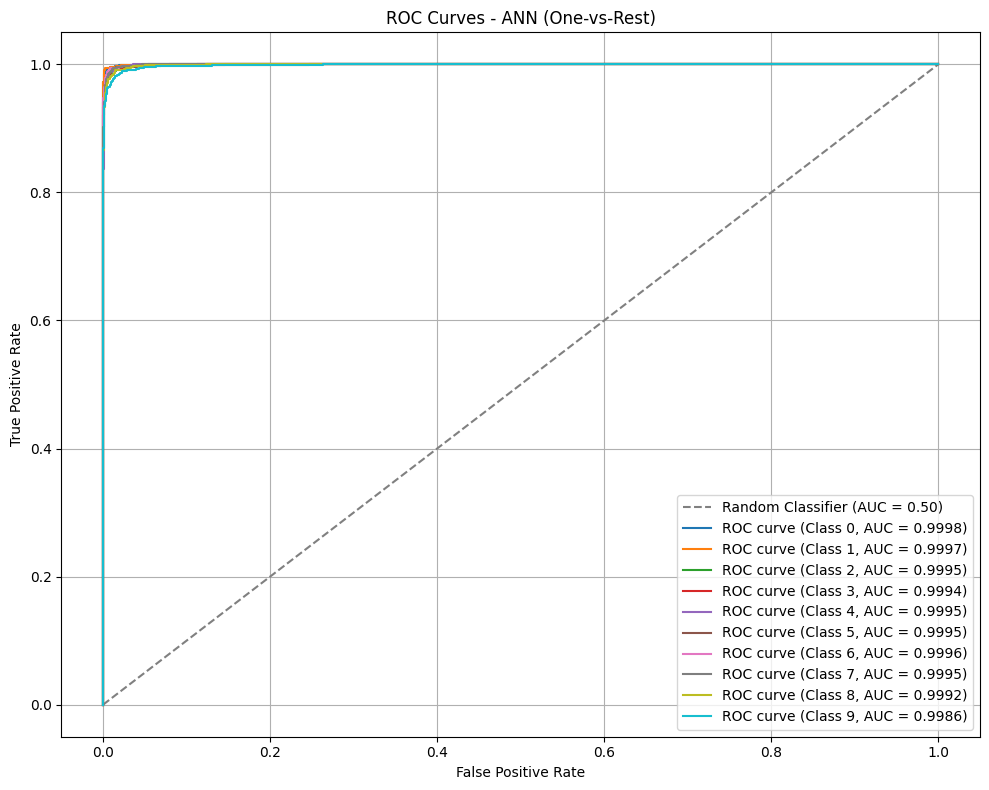

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt
import numpy as np

# Get predicted probabilities for each class
y_pred_prob = ann.predict(x_test_ann, verbose=0)

# Binarize y_test for one-vs-rest ROC
label_binarizer = LabelBinarizer()
y_test_binarized = label_binarizer.fit_transform(y_test)
n_classes = y_test_binarized.shape[1]

# Plotting ROC curves for each class (One-vs-Rest)
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier (AUC = 0.50)')

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_prob[:, i])
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve (Class {i}, AUC = {roc_auc_val:.4f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - ANN (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()